# Transverse-Field Ising Phase Transition Filtering

This notebook uses a small transverse-field Ising chain as a concrete condensed-matter model. The exact spectrum shows the finite-size precursor of the quantum phase transition near transverse field $h/J = 1$.

A low-energy QSVT-style polynomial projector is then applied near one field value to isolate the ground-state sector from the rest of the spectrum.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.hamiltonians import ising_hamiltonian, pauli_string_matrix
from qsvt.matrix_functions import design_low_energy_projector_polynomial
from qsvt.polynomials import eval_polynomial
from qsvt.rescaling import rescale_hermitian_about_cutoff
from qsvt.spectral import apply_polynomial_to_hermitian, eigh_hermitian

np.set_printoptions(precision=4, suppress=True)

In [2]:
n_spins = 5
fields = np.linspace(0.2, 1.8, 25)

magnetization_op = (
    sum(
        pauli_string_matrix(
            "".join("Z" if site == i else "I" for site in range(n_spins))
        ).real
        for i in range(n_spins)
    )
    / n_spins
)
magnetization_squared_op = magnetization_op @ magnetization_op

gaps = []
magnetizations = []
for h in fields:
    H = ising_hamiltonian(n_spins, coupling=1.0, transverse_field=h, periodic=False)
    evals, evecs = eigh_hermitian(H)
    ground = evecs[:, 0]
    gaps.append(evals[2] - evals[0])
    magnetizations.append(np.vdot(ground, magnetization_squared_op @ ground).real)

gaps = np.asarray(gaps)
magnetizations = np.asarray(magnetizations)

fields[np.argmin(gaps)], np.min(gaps)

(np.float64(0.6000000000000001), np.float64(1.393735087532208))

## Low-energy polynomial projector

At one field value, choose a cutoff halfway between the ground and first excited levels. After shifting around that cutoff, eigenvalues below the cutoff map to positive scaled values, so a projector polynomial approximates the low-energy spectral projector.

In [3]:
target_field = 0.9
H = ising_hamiltonian(
    n_spins, coupling=1.0, transverse_field=target_field, periodic=False
)
evals, evecs = eigh_hermitian(H)
cutoff = 0.5 * (evals[0] + evals[1])
scaled = rescale_hermitian_about_cutoff(H, cutoff, low_energy_positive=True)
scaled_values_by_energy = (evals - scaled.offset) / scaled.scale
scaled_evals = np.linalg.eigvalsh(scaled.matrix)
scaled_gap = min(abs(scaled_values_by_energy[scaled_values_by_energy > 0]))

coeffs = design_low_energy_projector_polynomial(gap=0.55 * scaled_gap, degree=31)
projector_poly = apply_polynomial_to_hermitian(scaled.matrix, coeffs)
projector_eigenweights = eval_polynomial(coeffs, scaled_values_by_energy)

exact_ground_projector = np.outer(evecs[:, 0], evecs[:, 0].conj())
projector_error = np.linalg.norm(projector_poly - exact_ground_projector)
projector_eigenweights[:5], projector_error

(array([0.6633, 0.3367, 0.022 , 0.0906, 0.1137]),
 np.float64(0.6378859822744462))

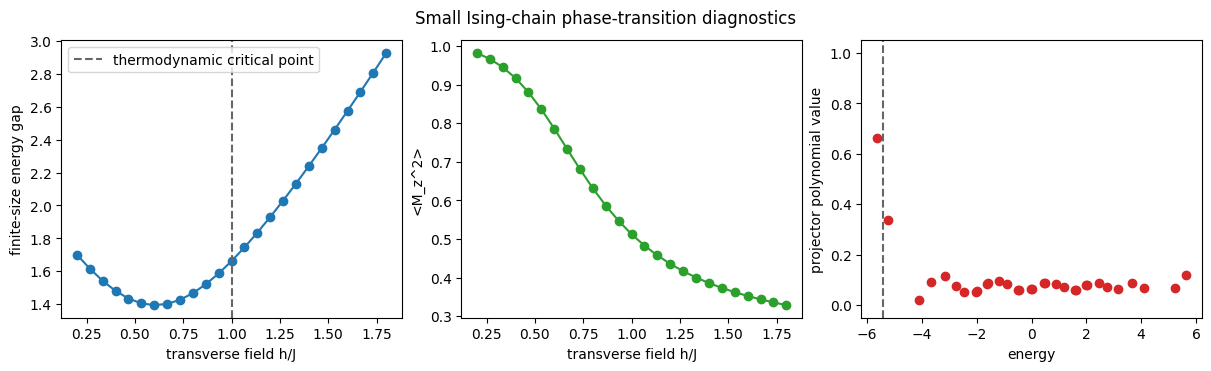

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), constrained_layout=True)

axes[0].plot(fields, gaps, "o-")
axes[0].axvline(1.0, color="0.4", linestyle="--", label="thermodynamic critical point")
axes[0].set_xlabel("transverse field h/J")
axes[0].set_ylabel("finite-size energy gap")
axes[0].legend()

axes[1].plot(fields, magnetizations, "o-", color="tab:green")
axes[1].set_xlabel("transverse field h/J")
axes[1].set_ylabel("<M_z^2>")

axes[2].scatter(evals, projector_eigenweights, color="tab:red")
axes[2].axvline(cutoff, color="0.4", linestyle="--")
axes[2].set_xlabel("energy")
axes[2].set_ylabel("projector polynomial value")
axes[2].set_ylim(-0.05, 1.05)

fig.suptitle("Small Ising-chain phase-transition diagnostics")
plt.show()

In [5]:
assert gaps[0] > gaps[np.argmin(np.abs(fields - 1.0))]
assert magnetizations[0] > magnetizations[-1]
assert projector_eigenweights[0] > projector_eigenweights[1]
assert projector_eigenweights[0] > 0.5
assert projector_error < 1.1

print(f"minimum_doublet_gap_field: {fields[np.argmin(gaps)]:.3f}")
print(f"magnetization_drop: {magnetizations[0] - magnetizations[-1]:.3f}")
print(f"projector_error: {projector_error:.3f}")
print("validation: passed")

minimum_doublet_gap_field: 0.600
magnetization_drop: 0.653
projector_error: 0.638
validation: passed
